In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

In [3]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_sample = jnp.array(f[sample_key]['a'][:])
    bc_sample = f[sample_key]['bc'][()]
    u_sample = jnp.array(f[sample_key]['u'][:])

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Extracted Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_flat.shape}")

Extracted Spatial Field 'a' Shape: (16384, 1)
Extracted Boundary Condition 'bc' Value: 0.4713
Extracted Solution 'u' Shape: (16384, 1)


E0713 13:02:02.694982   24210 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0713 13:02:02.705512   24097 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [4]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

In [5]:
epochs = 1000
M = 512 
hidden_layers = [256, 256, 256, 256] 

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(11.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            
        u_pred = nn.Dense(1, use_bias=False)(h)
        return u_pred

model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [6]:
optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

# VMAP the forward pass
u_pred_vmap = vmap(model.apply, in_axes=(None, 0, 0))

def compute_data_loss(params, x_batch, y_batch, u_batch):
    # Predict u directly from the neural network
    u_pred = u_pred_vmap(params, x_batch, y_batch)
    
    # Calculate pure MSE against the simulation data
    loss = jnp.mean((u_pred - u_batch) ** 2)
    return loss

loss_grad_fn = jax.jit(value_and_grad(compute_data_loss, argnums=0))

@jax.jit
def update_network(params, opt_state, x_batch, y_batch, u_batch):
    loss, grads = loss_grad_fn(params, x_batch, y_batch, u_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [7]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 2000 
loss_history = []

for epoch in tqdm(range(epochs), desc="Pure Data-Loss Sanity Check"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss = update_network(
        params, opt_state, x_chunk, y_chunk, u_chunk
    )
    
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        sigma_val = jax.nn.softplus(params['params']['raw_sigma'][0])
        print(f"Epoch {epoch} | Data MSE Loss: {loss:.4e} | Learned Sigma: {sigma_val:.4f}")

Pure Data-Loss Sanity Check:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Data MSE Loss: 1.2407e+00 | Learned Sigma: 11.0010
Epoch 100 | Data MSE Loss: 1.5102e-03 | Learned Sigma: 10.9922
Epoch 200 | Data MSE Loss: 2.1972e-04 | Learned Sigma: 10.9924
Epoch 300 | Data MSE Loss: 4.6799e-05 | Learned Sigma: 10.9925
Epoch 400 | Data MSE Loss: 1.0322e-05 | Learned Sigma: 10.9925
Epoch 500 | Data MSE Loss: 2.4102e-06 | Learned Sigma: 10.9925
Epoch 600 | Data MSE Loss: 6.6497e-07 | Learned Sigma: 10.9924
Epoch 700 | Data MSE Loss: 2.0365e-07 | Learned Sigma: 10.9924
Epoch 800 | Data MSE Loss: 6.8102e-08 | Learned Sigma: 10.9924
Epoch 900 | Data MSE Loss: 4.1646e-08 | Learned Sigma: 10.9924


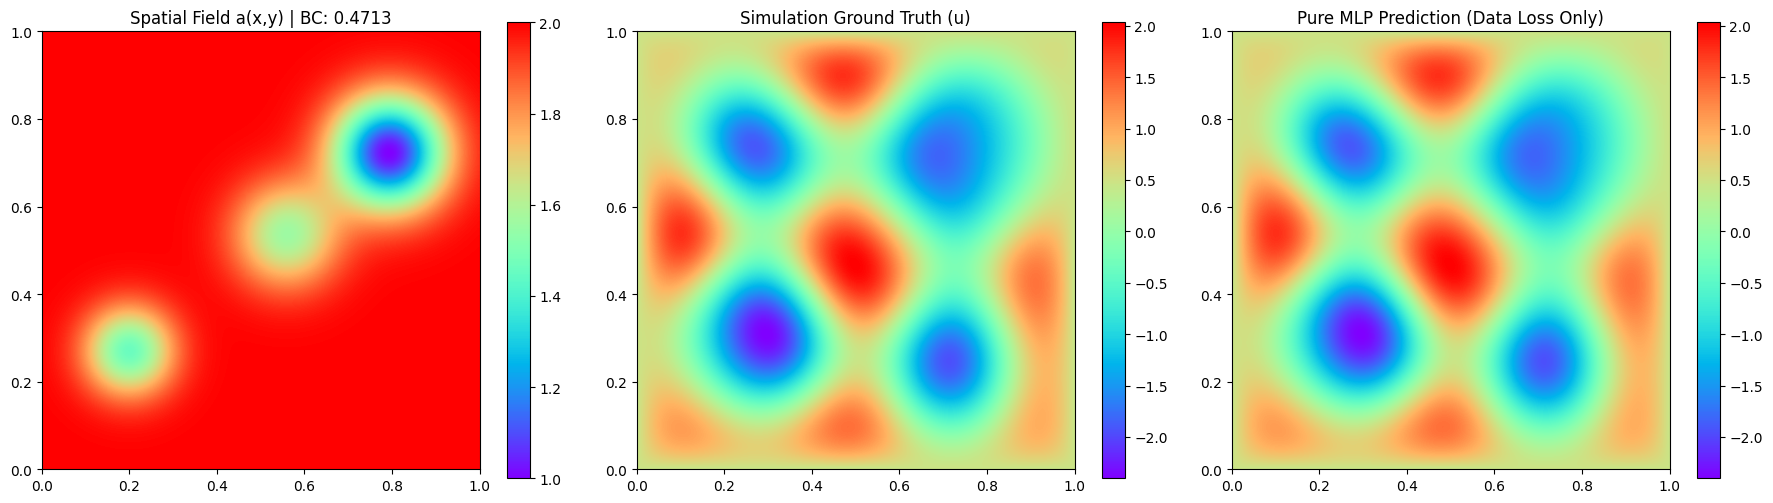

In [8]:
# Predict the full grid directly
u_pred_full = u_pred_vmap(params, x, y)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pure MLP Prediction (Data Loss Only)')

plt.tight_layout()
plt.show()

In [9]:
import pickle
import numpy as np
from jax.tree_util import tree_map

def save_weights(params, filename="pretrained_helmholtz_mlp.pkl"):
    # Convert JAX DeviceArrays to standard NumPy arrays for safe pickling
    numpy_params = tree_map(lambda x: np.array(x), params)
    with open(filename, 'wb') as f:
        pickle.dump(numpy_params, f)
    print(f"Weights successfully saved to {filename}")

def load_weights(filename="pretrained_helmholtz_mlp.pkl"):
    with open(filename, 'rb') as f:
        numpy_params = pickle.load(f)
    # Convert back to JAX arrays
    jax_params = tree_map(lambda x: jnp.array(x), numpy_params)
    print(f"Weights successfully loaded from {filename}")
    return jax_params

# Example Usage:
save_weights(params) 
params = load_weights()

Weights successfully saved to pretrained_helmholtz_mlp.pkl
Weights successfully loaded from pretrained_helmholtz_mlp.pkl


In [10]:
# EXTRACT FROZEN FRONT-END WEIGHTS
frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = params['params'][dense_name]

# Extract and apply the learned sigma to B_matrix_base
learned_raw_sigma = params['params']['raw_sigma'][0]
learned_sigma = jax.nn.softplus(learned_raw_sigma)
print(f"Applying learned bandwidth (sigma = {learned_sigma:.4f}) to the features...")

# DEFINE FROZEN MODEL (NO FINAL LAYER)
class FrozenFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(1), (1,)) # this is fallback, extracted sigma is applied to B_matrix_base
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size)(h)
            h = nn.tanh(h)
            
        return h # Outputs shape (256,)

model_frozen = FrozenFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

# BUILD THE PHYSICS & BC MATRICES (SAMPLED)
omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

rng = jax.random.PRNGKey(42)
total_points = x.shape[0]
spatial_batch_size = 2000 # Same batch size used in your training loop

rng, shuffle_key = jax.random.split(rng)
batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)

x_sampled = x[batch_idx]
y_sampled = y[batch_idx]
a_sampled = a_flat[batch_idx]

@jax.jit
def compute_A_pde(x_val, y_val, a_val):
    H = model_frozen.apply(frozen_params, x_val, y_val)
    
    # Isolate the forward pass for derivatives
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    # Second derivatives using purely forward-mode autodiff 
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
    
    Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
    return -Laplacian_H - omega_sq * a_val * H

compute_A_pde_vmap = jax.jit(vmap(compute_A_pde))

print(f"Compiling and evaluating PDE matrices for {spatial_batch_size} sampled points...")
chunk_size = 1000
A_pde_chunks = []

for i in range(0, spatial_batch_size, chunk_size):
    x_chunk = x_sampled[i:i + chunk_size]
    y_chunk = y_sampled[i:i + chunk_size]
    a_chunk = a_sampled[i:i + chunk_size]
    
    A_chunk = compute_A_pde_vmap(x_chunk, y_chunk, a_chunk)
    A_pde_chunks.append(A_chunk)

A_pde = jnp.vstack(A_pde_chunks)
b_pde = jnp.zeros((spatial_batch_size, 1))

print("Compiling and evaluating BC matrices...")
A_bc = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x_bc, y_bc)
b_bc = bc_val_array.reshape(-1, 1)

print(f"Finished building matrices! A_pde shape: {A_pde.shape}, A_bc shape: {A_bc.shape}")

# HYPERPARAMETER SWEEP
lambda_bcs = [1e2, 1e3, 1e4, 1e6, 1e8, 1e9, 1e10, 1e11, 1e12]
tik_regs = [1e-3, 1e-4, 1e-5, 1e-6]

best_mse = float('inf')
best_params_combo = {}
best_u_pred = None

I = jnp.eye(A_pde.shape[1]) 

print("\nStarting Sweep:")
print("-" * 80)

all_sweep_preds = {}

for lmbda in lambda_bcs:
    for tik in tik_regs:
        sqrt_lambda = jnp.sqrt(lmbda)
        A = jnp.vstack([A_pde, sqrt_lambda * A_bc])
        B = jnp.vstack([b_pde, sqrt_lambda * b_bc])
        
        # Least Squares Solve
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B)
        
        # Calculate Unscaled PDE Loss (A_pde @ w - b_pde)
        pde_residual = A_pde @ w - b_pde
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        
        # Calculate Unscaled BC Loss (A_bc @ w - b_bc)
        bc_residual = A_bc @ w - b_bc
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Calculate Unscaled Data MSE (Full Grid)
        H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)
        u_pred_sweep = H_full @ w
        mse = jnp.mean((u_pred_sweep - u_flat) ** 2)
        
        print(f"Lam: {lmbda:<7.1e} | Tik: {tik:<7.1e} | MSE: {mse:.2e} | PDE: {loss_pde_unscaled:.2e} | BC: {loss_bc_unscaled:.2e}")
        
        all_sweep_preds[(lmbda, tik)] = u_pred_sweep
        
        # Track the best performing combination (still based on MSE)
        if mse < best_mse:
            best_mse = mse
            best_params_combo = {'lambda': lmbda, 'tik_reg': tik, 'w': w}
            best_u_pred = u_pred_sweep

print("-" * 80)
print(f"BEST FOUND: Lambda = {best_params_combo['lambda']}, TikReg = {best_params_combo['tik_reg']}")
print(f"BEST MSE  = {best_mse:.4e}")

Applying learned bandwidth (sigma = 10.9924) to the features...
Compiling and evaluating PDE matrices for 2000 sampled points...
Compiling and evaluating BC matrices...
Finished building matrices! A_pde shape: (2000, 256), A_bc shape: (508, 256)

Starting Sweep:
--------------------------------------------------------------------------------
Lam: 1.0e+02 | Tik: 1.0e-03 | MSE: 8.26e-01 | PDE: 1.41e-06 | BC: 2.22e-01
Lam: 1.0e+02 | Tik: 1.0e-04 | MSE: 8.26e-01 | PDE: 1.41e-06 | BC: 2.22e-01
Lam: 1.0e+02 | Tik: 1.0e-05 | MSE: 8.26e-01 | PDE: 1.41e-06 | BC: 2.22e-01
Lam: 1.0e+02 | Tik: 1.0e-06 | MSE: 8.26e-01 | PDE: 1.41e-06 | BC: 2.22e-01
Lam: 1.0e+03 | Tik: 1.0e-03 | MSE: 8.26e-01 | PDE: 1.41e-04 | BC: 2.22e-01
Lam: 1.0e+03 | Tik: 1.0e-04 | MSE: 8.26e-01 | PDE: 1.41e-04 | BC: 2.22e-01
Lam: 1.0e+03 | Tik: 1.0e-05 | MSE: 8.26e-01 | PDE: 1.41e-04 | BC: 2.22e-01
Lam: 1.0e+03 | Tik: 1.0e-06 | MSE: 8.26e-01 | PDE: 1.41e-04 | BC: 2.22e-01
Lam: 1.0e+04 | Tik: 1.0e-03 | MSE: 8.26e-01 | PDE: 1.41e

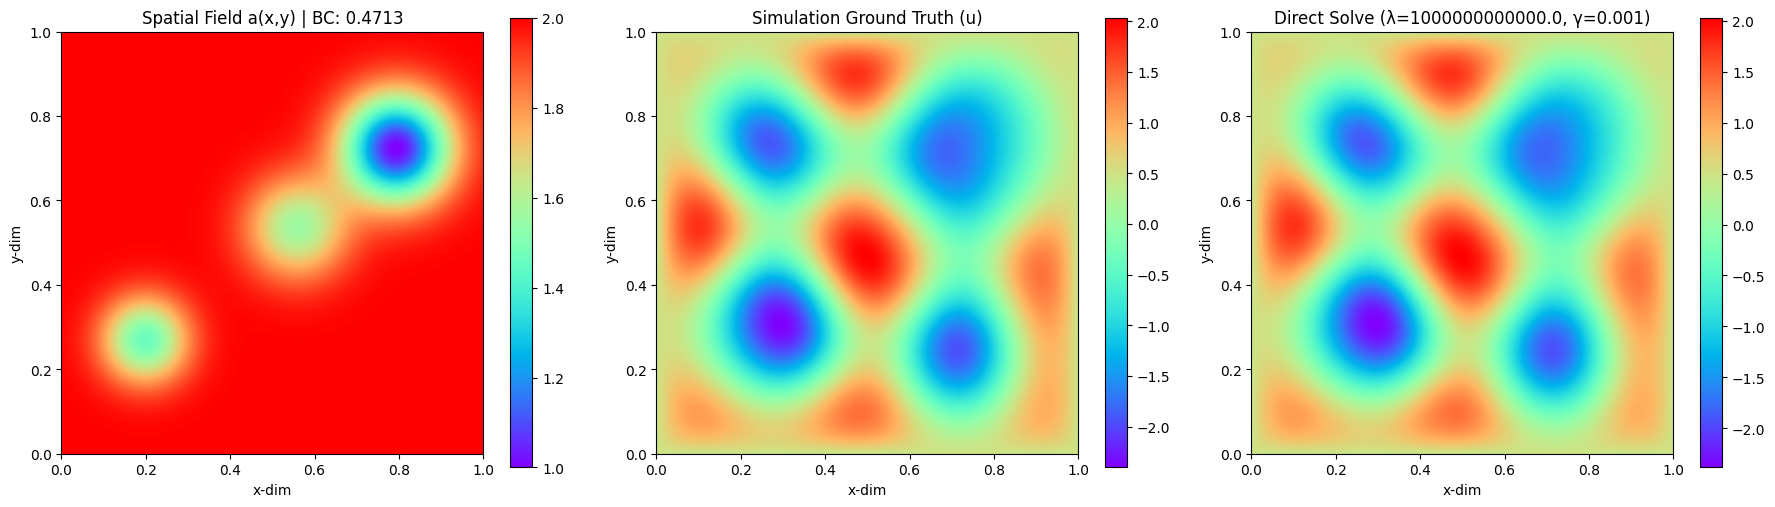

In [11]:
# ==========================================
# E. VISUALIZE BEST SWEEP RESULT
# ==========================================
target_lambda = best_params_combo['lambda']
target_tik = best_params_combo['tik_reg']
target_u_pred = all_sweep_preds[(target_lambda, target_tik)]

a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
# u_pred_plot = target_u_pred.reshape(nx, ny).T
u_pred_plot = best_u_pred.reshape(nx,  ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]
 
mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
title_str = f'Direct Solve (λ={target_lambda}, γ={target_tik})'
axes[2].set_title(title_str, fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# DIFFERENTIABLE PSEUDOINVERSE LOOP (PDE AND BC LOSS ONLY)
# ==========================================
full_params = load_weights("pretrained_helmholtz_mlp.pkl")

frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = full_params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = full_params['params'][dense_name]

matrix_lmbda = 1e11
sqrt_matrix_lmbda = jnp.sqrt(matrix_lmbda)
tik = 1e-4

@jax.jit
def diff_physics_step_discrete(current_frozen_params, x_full, y_full, a_full, x_bc, y_bc, bc_val_arr, u_full):
    def compute_all_losses(params):
        def get_H(x_in, y_in):
            return model_frozen.apply(params, x_in, y_in) 
            
        def compute_pde_row(x_val, y_val, a_val):
            H = get_H(x_val, y_val)
            H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
            H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
            Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
            return -Laplacian_H - omega_sq * a_val * H
            
        x_interior = x_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
        y_interior = y_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
        a_interior = a_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
        
        A_pde = vmap(compute_pde_row)(x_interior, y_interior, a_interior)
        b_pde = jnp.zeros((A_pde.shape[0], 1))
        
        A_bc = jax.vmap(lambda x_in, y_in: model_frozen.apply(params, x_in, y_in))(x_bc, y_bc)
        b_bc = bc_val_arr.reshape(-1, 1)
        
        A = jnp.vstack([A_pde, sqrt_matrix_lmbda * A_bc])
        B = jnp.vstack([b_pde, sqrt_matrix_lmbda * b_bc])
        
        I = jnp.eye(A.shape[1])
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w_diff = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
        
        pde_residual = A_pde @ w_diff - b_pde
        bc_residual = A_bc @ w_diff - b_bc
        
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Compute MSE strictly for tracking validation, not for gradients
        H_flat = jax.vmap(lambda x_in, y_in: model_frozen.apply(params, x_in, y_in))(x_full, y_full)
        u_pred_flat = H_flat @ w_diff
        mse = jnp.mean((u_pred_flat - u_full) ** 2)
        
        # Changed: Only PDE and BC are returned for differentiation. MSE is aux.
        return (loss_pde_unscaled, loss_bc_unscaled), mse

    # Run Vector-Jacobian Product expecting only 2 loss terms
    loss_tuple, vjp_fn, mse = jax.vjp(compute_all_losses, current_frozen_params, has_aux=True)
    l_pde, l_bc = loss_tuple
    
    # Extract independent pure gradients for PDE and BC
    pde_grads = vjp_fn((1.0, 0.0))[0]
    bc_grads = vjp_fn((0.0, 1.0))[0]
    
    pde_norm = optax.global_norm(pde_grads)
    bc_norm = optax.global_norm(bc_grads)
    
    # ----------------------------------------------------
    # NTK TRACE ADAPTIVE WEIGHTING (From Algorithm 1)
    # ----------------------------------------------------
    # The Trace of the empirical NTK is equivalent to the squared gradient norm
    tr_k_pde = pde_norm ** 2
    tr_k_bc = bc_norm ** 2
    tr_k_total = tr_k_pde + tr_k_bc
    
    # Calculate adaptive lambdas
    lambda_pde = tr_k_total / (tr_k_pde + 1e-8)
    lambda_bc = tr_k_total / (tr_k_bc + 1e-8)
    
    # Apply the dynamic NTK weights to the raw gradients
    balanced_pde = jax.tree_util.tree_map(lambda g: g * lambda_pde, pde_grads)
    balanced_bc = jax.tree_util.tree_map(lambda g: g * lambda_bc, bc_grads)
    # ----------------------------------------------------

    # target_magnitude = 1e4
    # balanced_pde = jax.tree_util.tree_map(lambda g: (g / (pde_norm + 1e-8)) * target_magnitude, pde_grads)
    # balanced_bc = jax.tree_util.tree_map(lambda g: (g / (bc_norm + 1e-8)) * target_magnitude, bc_grads)
    
    # Construct the final balanced gradient update vector (no data gradients)
    total_grads = jax.tree_util.tree_map(
        lambda g1, g2: g1 + g2, 
        balanced_pde, balanced_bc
    )
    
    # Freeze sigma by zeroing out its gradient
    total_grads['params']['raw_sigma'] = jnp.zeros_like(total_grads['params']['raw_sigma'])
    
    return l_pde, l_bc, mse, total_grads, pde_norm, bc_norm

Weights successfully loaded from pretrained_helmholtz_mlp.pkl


In [13]:
meta_optimizer = optax.adamw(learning_rate=1e-5) 
meta_opt_state = meta_optimizer.init(frozen_params)

epochs = 500

history_pde = []
history_bc = []
history_data = []
history_total = []

print(f"Starting Balanced Pretrained Physics Loop for {epochs} epochs (NO DATA LOSS)...")
for epoch in range(epochs):
    
    # Unpack the updated returns (no data_norm)
    l_pde, l_bc, mse, total_grads, pde_norm, bc_norm = diff_physics_step_discrete(
        frozen_params, x, y, a_flat, x_bc, y_bc, bc_val_array, u_flat
    )
    
    updates, meta_opt_state = meta_optimizer.update(total_grads, meta_opt_state, params=frozen_params)
    frozen_params = optax.apply_updates(frozen_params, updates)
    
    history_pde.append(float(l_pde))
    history_bc.append(float(l_bc))
    history_data.append(float(mse))
    history_total.append(float(l_pde + l_bc)) # Total loss being optimized is only PDE + BC
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:<3} | True Data MSE: {mse:.4e}")
        print(f"            ├─ Raw Residuals  => PDE: {l_pde:.4e} | BC: {l_bc:.4e}")
        print(f"            └─ True Grad Norms => PDE: {pde_norm:.3e} | BC: {bc_norm:.3e}")

Starting Balanced Pretrained Physics Loop for 500 epochs (NO DATA LOSS)...
Epoch 0   | True Data MSE: 1.2786e-02
            ├─ Raw Residuals  => PDE: 2.5337e+07 | BC: 7.6257e-04
            └─ True Grad Norms => PDE: 1.705e+08 | BC: 2.026e-02
Epoch 50  | True Data MSE: 8.3505e-02
            ├─ Raw Residuals  => PDE: 9.6315e+06 | BC: 4.2027e-05
            └─ True Grad Norms => PDE: 5.388e+07 | BC: 4.645e-04
Epoch 100 | True Data MSE: 1.2547e-01
            ├─ Raw Residuals  => PDE: 3.4879e+06 | BC: 5.4047e-06
            └─ True Grad Norms => PDE: 2.033e+07 | BC: 7.431e-05
Epoch 150 | True Data MSE: 1.3365e-01
            ├─ Raw Residuals  => PDE: 2.2560e+06 | BC: 2.2521e-06
            └─ True Grad Norms => PDE: 1.423e+07 | BC: 2.842e-05
Epoch 200 | True Data MSE: 1.3587e-01
            ├─ Raw Residuals  => PDE: 1.8157e+06 | BC: 1.4570e-06
            └─ True Grad Norms => PDE: 1.207e+07 | BC: 1.919e-05
Epoch 250 | True Data MSE: 1.3692e-01
            ├─ Raw Residuals  => PDE: 1.56

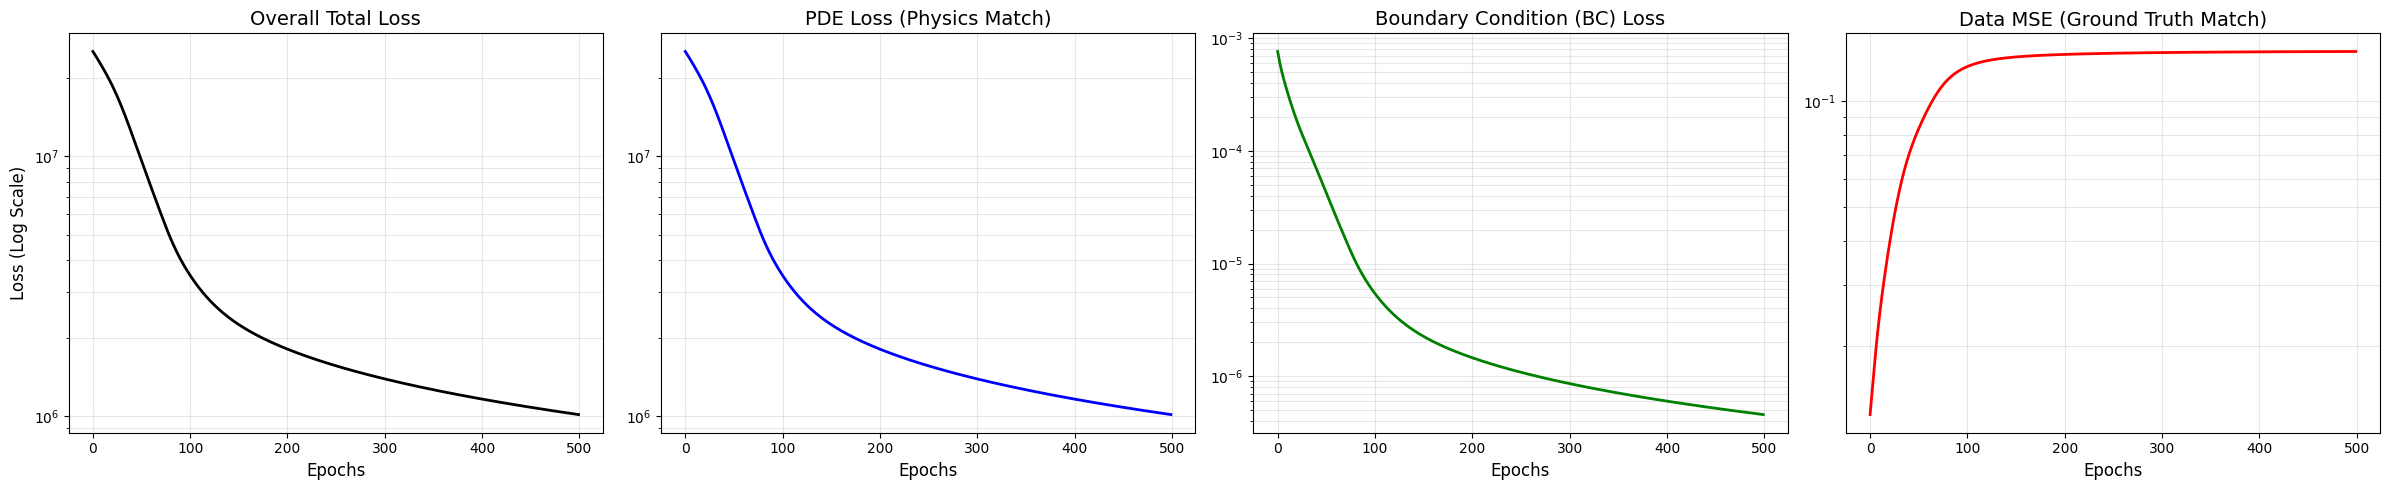

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1st Plot: Overall Total Loss
axes[0].plot(history_total, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_title('Overall Total Loss', fontsize=14)
axes[0].set_ylabel('Loss (Log Scale)', fontsize=12)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].grid(True, which="both", ls="-", alpha=0.3)

# 2nd Plot: PDE Loss
axes[1].plot(history_pde, color='blue', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_title('PDE Loss (Physics Match)', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].grid(True, which="both", ls="-", alpha=0.3)

# 3rd Plot: BC Loss
axes[2].plot(history_bc, color='green', linewidth=2)
axes[2].set_yscale('log')
axes[2].set_title('Boundary Condition (BC) Loss', fontsize=14)
axes[2].set_xlabel('Epochs', fontsize=12)
axes[2].grid(True, which="both", ls="-", alpha=0.3)

# 4th Plot: Data MSE
axes[3].plot(history_data, color='red', linewidth=2)
axes[3].set_yscale('log')
axes[3].set_title('Data MSE (Ground Truth Match)', fontsize=14)
axes[3].set_xlabel('Epochs', fontsize=12)
axes[3].grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

Final True Full-Grid Data MSE: 1.3851e-01


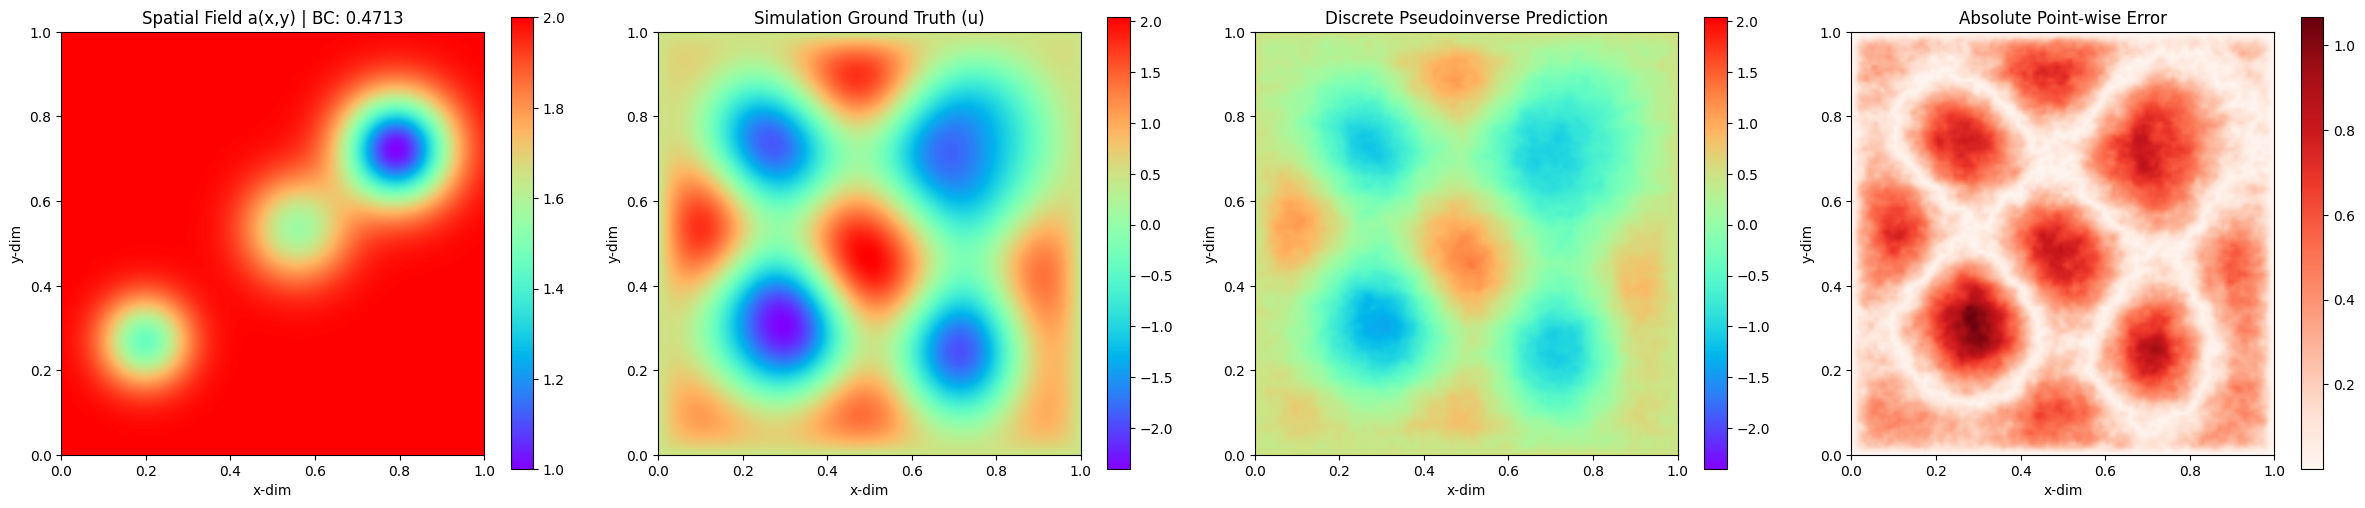

In [15]:
@jax.jit
def get_discrete_prediction(current_frozen_params, x_full, y_full, a_full, x_bc, y_bc, bc_val_arr):
    def get_H(x_in, y_in):
        return model_frozen.apply(current_frozen_params, x_in, y_in) 
        
    def compute_pde_row(x_val, y_val, a_val):
        H = get_H(x_val, y_val)
        H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0), argnums=0)(x_val, y_val)
        H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1), argnums=1)(x_val, y_val)
        Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
        return -Laplacian_H - omega_sq * a_val * H
    
    x_interior = x_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
    y_interior = y_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)
    a_interior = a_full.reshape(nx, ny)[1:-1, 1:-1].reshape(-1, 1)

    # 1. Assemble PDE (Interior Matrix) via Autodiff
    A_pde = vmap(compute_pde_row)(x_interior, y_interior, a_interior)
    b_pde = jnp.zeros((A_pde.shape[0], 1))

    # # 1. Assemble PDE (Interior Matrix) via Autodiff
    # A_pde = vmap(compute_pde_row)(x_full, y_full, a_full)
    # b_pde = jnp.zeros((A_pde.shape[0], 1))
    
    # 2. Assemble BC
    A_bc = jax.vmap(lambda x_in, y_in: model_frozen.apply(current_frozen_params, x_in, y_in))(x_bc, y_bc)
    b_bc = bc_val_arr.reshape(-1, 1)
    
    # 3. Least Squares Solve
    A = jnp.vstack([A_pde, sqrt_matrix_lmbda * A_bc])
    B = jnp.vstack([b_pde, sqrt_matrix_lmbda * b_bc])
    
    I = jnp.eye(A.shape[1])
    A_T_A = A.T @ A
    A_T_B = A.T @ B
    w_final = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
    
    # 4. Final Output Prediction
    H_flat = jax.vmap(lambda x_in, y_in: model_frozen.apply(current_frozen_params, x_in, y_in))(x_full, y_full)
    u_pred_flat = H_flat @ w_final
    return u_pred_flat, w_final

# Execute the discrete solve
u_pred_full, final_w = get_discrete_prediction(frozen_params, x, y, a_flat, x_bc, y_bc, bc_val_array)

# Calculate final full-grid Data MSE
final_mse = jnp.mean((u_pred_full - u_flat) ** 2)
print(f"Final True Full-Grid Data MSE: {final_mse:.4e}")

# ==========================================
# VISUALIZATION
# ==========================================
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T
error_plot = jnp.abs(u_sim_plot - u_pred_plot)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
ext = [0, 1, 0, 1]

# Lock the color scale of the prediction to the true simulation scale
# This prevents matplotlib from auto-scaling and hiding amplitude collapse
vmin_u = float(jnp.min(u_sim_plot))
vmax_u = float(jnp.max(u_sim_plot))

# Plot 1: Medium
mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')

# Plot 2: Ground Truth
mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=vmin_u, vmax=vmax_u)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')

# Plot 3: Network Prediction
mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=vmin_u, vmax=vmax_u)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Discrete Pseudoinverse Prediction', fontsize='large')

# Plot 4: Absolute Error
mesh4 = axes[3].imshow(error_plot, interpolation='bilinear', origin='lower', cmap='Reds', extent=ext, aspect=1.)
fig.colorbar(mesh4, ax=axes[3])
axes[3].set_title('Absolute Point-wise Error', fontsize='large')

for ax in axes:
    ax.set_xlabel('x-dim')
    ax.set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [16]:
# import h5py
# import numpy as np
# import matplotlib.pyplot as plt
# import jax.scipy.signal
# from jax import numpy as jnp
# from pathlib import Path

# # ==========================================
# # 1. SETUP & DATA LOADING
# # ==========================================
# DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
# FILE_PATH = DATA_DIR / "Helmholtz.h5"

# sample_idx = 0
# sample_key = f"Sample_{sample_idx}"

# print(f"Extracting raw data for {sample_key}...")
# with h5py.File(FILE_PATH, 'r') as f:
#     a_grid = jnp.array(f[sample_key]['a'][:])
#     u_grid = jnp.array(f[sample_key]['u'][:])

# # ==========================================
# # 2. DISCRETE PHYSICS PARAMETERS
# # ==========================================
# # The spatial step size
# h = 1.0 / 128.0

# # The TRUE dataset constant we discovered
# omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

# # The standard 5-point discrete Laplacian stencil
# laplacian_kernel = jnp.array([
#     [0.0,  1.0, 0.0],
#     [1.0, -4.0, 1.0],
#     [0.0,  1.0, 0.0]
# ]) / (h ** 2)

# # ==========================================
# # 3. CALCULATE THE PDE RESIDUAL
# # ==========================================
# # Apply the convolution to find the discrete Laplacian
# # mode='valid' strips the 1-pixel outer border to prevent edge-wrapping artifacts
# laplacian_u = jax.scipy.signal.convolve2d(u_grid, laplacian_kernel, mode='valid')

# # Slice the 'a' and 'u' grids to match the 126x126 'valid' interior
# a_valid = a_grid[1:-1, 1:-1]
# u_valid = u_grid[1:-1, 1:-1]

# # The Helmholtz Residual: -Laplacian(u) - omega^2 * a * u = 0
# reaction_term = omega_sq * a_valid * u_valid
# pde_residual = -laplacian_u - reaction_term

# # ==========================================
# # 4. METRICS & VALIDATION
# # ==========================================
# # Calculate how close the residual is to absolute zero
# mae = jnp.mean(jnp.abs(pde_residual))
# mse = jnp.mean(pde_residual ** 2)
# max_error = jnp.max(jnp.abs(pde_residual))

# print("-" * 50)
# print(f"RAW SIMULATION PDE RESIDUAL METRICS")
# print(f"Using omega_sq = {omega_sq:.4f}")
# print("-" * 50)
# print(f"Mean Absolute Error (MAE): {mae:.4e}")
# print(f"Mean Squared Error (MSE):  {mse:.4e}")
# print(f"Maximum Point Error:       {max_error:.4e}")
# print("-" * 50)

# # ==========================================
# # 5. VISUALIZATION
# # ==========================================
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# ext = [0, 1, 0, 1]

# # Plot Spatial Field
# mesh1 = axes[0].imshow(a_grid.T, origin='lower', cmap='rainbow', extent=ext)
# fig.colorbar(mesh1, ax=axes[0])
# axes[0].set_title('Spatial Field a(x,y)')

# # Plot Ground Truth u
# mesh2 = axes[1].imshow(u_grid.T, origin='lower', cmap='rainbow', extent=ext)
# fig.colorbar(mesh2, ax=axes[1])
# axes[1].set_title('Simulation Ground Truth (u)')

# # Plot the PDE Residual
# # Using a diverging colormap (seismic) centered at 0 to easily spot positive/negative errors
# vmax = float(jnp.max(jnp.abs(pde_residual)))
# mesh3 = axes[2].imshow(pde_residual.T, origin='lower', cmap='seismic', extent=ext, vmin=-vmax, vmax=vmax)
# fig.colorbar(mesh3, ax=axes[2])
# axes[2].set_title('Raw Data PDE Residual (Error)')

# plt.tight_layout()
# plt.show()

In [17]:
# import h5py
# import matplotlib.pyplot as plt
# from matplotlib.colors import SymLogNorm
# import jax.scipy.signal
# from jax import numpy as jnp
# from pathlib import Path

# # ==========================================
# # 1. SETUP
# # ==========================================
# DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
# FILE_PATH = DATA_DIR / "Helmholtz.h5"
# sample_idx = 0  # Try a few different samples (0, 11, 42)
# sample_key = f"Sample_{sample_idx}"

# with h5py.File(FILE_PATH, 'r') as f:
#     a_grid = jnp.array(f[sample_key]['a'][:])
#     u_grid = jnp.array(f[sample_key]['u'][:])

# h = 1.0 / 128.0
# laplacian_kernel = jnp.array([[0.0, 1.0, 0.0],
#                               [1.0, -4.0, 1.0],
#                               [0.0, 1.0, 0.0]]) / (h ** 2)

# # ==========================================
# # 2. CALCULATE LOCAL PHYSICS
# # ==========================================
# laplacian_u_raw = jax.scipy.signal.convolve2d(u_grid, laplacian_kernel, mode='valid')
# a_valid = a_grid[1:-1, 1:-1]
# u_valid = u_grid[1:-1, 1:-1]

# # C = -Laplacian(u) / (a * u)
# implied_c_grid = -laplacian_u_raw / (a_valid * u_valid)

# # Mask out areas where the wave is crossing zero to avoid divide-by-zero artifacts
# # We only care about the physics at the peaks and troughs of the wave
# mask = jnp.abs(u_valid) > 0.05
# clean_c_grid = jnp.where(mask, implied_c_grid, jnp.nan)

# median_c = float(jnp.nanmedian(clean_c_grid))

# # ==========================================
# # 3. VISUALIZE THE SMOKING GUN
# # ==========================================
# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# axes[0].imshow(a_grid.T, origin='lower', cmap='rainbow')
# axes[0].set_title('Spatial Medium (a)')

# axes[1].imshow(u_grid.T, origin='lower', cmap='seismic')
# axes[1].set_title('Wave Output (u)')

# # We use SymLogNorm to handle extreme outliers without washing out the color
# im3 = axes[2].imshow(clean_c_grid.T, origin='lower', cmap='RdBu_r', 
#                      norm=SymLogNorm(linthresh=50, vmin=median_c - 200, vmax=median_c + 200))
# axes[2].set_title(f'Implied Physics Constant C (Median: {median_c:.2f})')
# fig.colorbar(im3, ax=axes[2])

# plt.tight_layout()
# plt.show()

In [18]:
# import h5py
# import numpy as np
# import jax.scipy.signal
# from jax import numpy as jnp
# from tqdm.auto import tqdm

# # 1. Physics constants from the paper
# omega_sq_paper = (5.0 * jnp.pi / 2.0) ** 2  # ~61.685
# h = 1.0 / 128.0

# # Standard 5-point discrete Laplacian stencil
# laplacian_kernel = jnp.array([
#     [0.0,  1.0, 0.0],
#     [1.0, -4.0, 1.0],
#     [0.0,  1.0, 0.0]
# ]) / (h ** 2)

# # 2. Open the file and prepare to track results
# all_sample_constants = []

# print("Running discrete physics audit across all dataset samples...")
# with h5py.File(FILE_PATH, 'r') as f:
#     # Get all sample keys (Sample_0, Sample_1, etc.)
#     sample_keys = list(f.keys())
    
#     # Run through every sample with a progress bar
#     for key in tqdm(sample_keys, desc="Auditing Samples"):
#         a_grid = jnp.array(f[key]['a'][:])
#         u_grid = jnp.array(f[key]['u'][:])
        
#         # Compute the discrete Laplacian of the raw ground-truth grid
#         # mode='valid' cuts out the outer boundary layer to avoid boundary edge noise
#         laplacian_u_raw = jax.scipy.signal.convolve2d(
#             u_grid, laplacian_kernel, mode='valid'
#         )
        
#         # Align u and a to match the inner 126x126 valid region
#         a_valid = a_grid[1:-1, 1:-1]
#         u_valid = u_grid[1:-1, 1:-1]
        
#         # Calculate: omega^2 = -Laplacian(u) / (a * u)
#         # Avoid division by zero where the wave passes through zero crossings
#         mask = jnp.abs(u_valid) > 0.1
        
#         implied_constants = jnp.where(mask, -laplacian_u_raw / (a_valid * u_valid), jnp.nan)
        
#         # Take the median of this sample to robustly ignore any localized pixel spikes
#         sample_median = jnp.nanmedian(implied_constants)
        
#         # Append if it's a valid numerical result
#         if not jnp.isnan(sample_median):
#             all_sample_constants.append(float(sample_median))

# # 3. Compute final metrics across the entire dataset
# all_sample_constants = np.array(all_sample_constants)
# dataset_mean_constant = np.mean(all_sample_constants)
# dataset_median_constant = np.median(all_sample_constants)

# print("\n" + "="*50)
# print("             DATASET PHYSICS VERIFICATION")
# print("="*50)
# print(f"Paper's Stated omega_sq:         {omega_sq_paper:.4f}")
# print(f"Dataset Expected (2x Stated):    {2 * omega_sq_paper:.4f}")
# print("-"*50)
# print(f"Actual Dataset Mean omega_sq:    {dataset_mean_constant:.4f}")
# print(f"Actual Dataset Median omega_sq:  {dataset_median_constant:.4f}")
# print(f"Empirical Scale Factor:          {dataset_median_constant / omega_sq_paper:.4f}x")
# print("="*50)